Diffusers and pipeline Code

In [1]:
from diffusers import StableDiffusion3Pipeline
import torch
from config import LAM_VALUES, TSR_DIR, PT_TSR_DIR, PROMPTS_FILE, MODEL_CACHE, SEED, TSR_SIGMA, SWAP_ALGORITHM, N_INF_STEPS, GUIDANCE_SCALE

    # ── Load model once ───────────────────────────────────────────────────────────
pipe = StableDiffusion3Pipeline.from_pretrained(
	"stabilityai/stable-diffusion-3-medium-diffusers",
	torch_dtype=torch.float16,
	cache_dir=MODEL_CACHE,
)
pipe = pipe.to("cuda")
pipe.set_progress_bar_config(disable=True)

Loading pipeline components...:   0%|          | 0/9 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/219 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Imports, configs

In [2]:
from pathlib import Path
import gc
import pandas as pd
from tqdm import tqdm
import shutil

TSR_DIR     = Path("/n/netscratch/kempner_undergrads/Everyone/zwu/parallel_toy/images/tsr_samples_tester_new")
PT_TSR_DIR  = Path("/n/netscratch/kempner_undergrads/Everyone/zwu/parallel_toy/images/pt_samples_tester_new")

REPLICA_EXCHANGE = True
LAM_VALUES = [2.0]
INDEX_UNTIL = 6

gc.collect()
torch.cuda.empty_cache()

SWAP_ALGORITHM = {
	"n_replicas": 2,
	"p_ratio": "p",
	"even_indices": [1, 2, 3, 4, 5, 6, 7, 8, 9, 12, 16, 21],
	"odd_indices": 	[],
	"debug": True,
}
    

In [3]:
if PT_TSR_DIR.exists():
    shutil.rmtree(PT_TSR_DIR)

Sample!

In [4]:
# ── Load prompts once ─────────────────────────────────────────────────────────
prompts = pd.read_csv(PROMPTS_FILE, usecols=["text"], nrows=INDEX_UNTIL)["text"].tolist()
print(f"Loaded {len(prompts)} prompts")


replica_exchanges = [False, True]

lam_dirs = {}
for re in replica_exchanges:
	base = PT_TSR_DIR if re else TSR_DIR
	lam_dirs[re] = {l: base / f"lam{l:.3f}".replace(".", "p") for l in LAM_VALUES}
	for d in lam_dirs[re].values():
		d.mkdir(parents=True, exist_ok=True)

# ── Sweep ─────────────────────────────────────────────────────────────────────
for idx, prompt in enumerate(prompts):
	
	for replica_exchange in replica_exchanges:
	
		for tsr_lam in tqdm(LAM_VALUES, desc=f"idx={idx} re={replica_exchange}"):

			output_dir = lam_dirs[replica_exchange][tsr_lam]

			if (output_dir / f"{idx:05d}.png").exists():
				continue

			generator = torch.Generator(device="cuda").manual_seed(SEED)

			images = pipe(
				prompt,
				negative_prompt="",
				num_inference_steps=N_INF_STEPS,
				guidance_scale=GUIDANCE_SCALE,
				tsr_lam=tsr_lam,
				tsr_sigma=TSR_SIGMA,
				replica_exchange=replica_exchange,
				swap_algorithm=SWAP_ALGORITHM,
				generator=generator,
			).images

			out_path = output_dir / f"{idx:05d}.png"
			images[0].save(out_path, icc_profile=None)


			del images
		torch.cuda.empty_cache()

print("\n All k values complete.")

Loaded 6 prompts


idx=0 re=True:   0%|          | 0/1 [00:00<?, ?it/s]

 We tsr by 2.00 with replica exchange True
Time 988.27 swap btwn source 0.50 and target 2.00 accept 0.999 std 0.978
Time 975.98 swap btwn source 0.50 and target 2.00 accept 0.962 std 0.968
Time 963.08 swap btwn source 0.50 and target 2.00 accept 0.995 std 0.958
Time 949.53 swap btwn source 0.50 and target 2.00 accept 0.955 std 0.948
Time 935.28 swap btwn source 0.50 and target 2.00 accept 0.990 std 0.938
Time 920.28 swap btwn source 0.50 and target 2.00 accept 0.960 std 0.928
Time 904.45 swap btwn source 0.50 and target 2.00 accept 0.988 std 0.917
Time 887.74 swap btwn source 0.50 and target 2.00 accept 0.964 std 0.907
Time 870.06 swap btwn source 0.50 and target 2.00 accept 0.987 std 0.896
Time 810.31 swap btwn source 0.50 and target 2.00 accept 0.981 std 0.861
Time 710.47 swap btwn source 0.50 and target 2.00 accept 0.992 std 0.813
Time 536.03 swap btwn source 0.50 and target 2.00 accept 0.993 std 0.754


idx=1 re=True:   0%|          | 0/1 [00:00<?, ?it/s]

 We tsr by 2.00 with replica exchange True
Time 988.27 swap btwn source 0.50 and target 2.00 accept 0.998 std 0.978
Time 975.98 swap btwn source 0.50 and target 2.00 accept 0.971 std 0.969
Time 963.08 swap btwn source 0.50 and target 2.00 accept 0.995 std 0.959
Time 949.53 swap btwn source 0.50 and target 2.00 accept 0.963 std 0.949
Time 935.28 swap btwn source 0.50 and target 2.00 accept 0.989 std 0.939
Time 920.28 swap btwn source 0.50 and target 2.00 accept 0.964 std 0.929
Time 904.45 swap btwn source 0.50 and target 2.00 accept 0.984 std 0.918
Time 887.74 swap btwn source 0.50 and target 2.00 accept 0.966 std 0.908
Time 870.06 swap btwn source 0.50 and target 2.00 accept 0.982 std 0.897
Time 810.31 swap btwn source 0.50 and target 2.00 accept 0.980 std 0.865
Time 710.47 swap btwn source 0.50 and target 2.00 accept 0.987 std 0.820
Time 536.03 swap btwn source 0.50 and target 2.00 accept 0.993 std 0.766


...

 We tsr by 2.00 with replica exchange True
Time 988.27 swap btwn source 0.50 and target 2.00 accept 0.999 std 0.978
Time 975.98 swap btwn source 0.50 and target 2.00 accept 0.985 std 0.968
Time 963.08 swap btwn source 0.50 and target 2.00 accept 0.999 std 0.958
Time 949.53 swap btwn source 0.50 and target 2.00 accept 0.987 std 0.947
Time 935.28 swap btwn source 0.50 and target 2.00 accept 0.998 std 0.937
Time 920.28 swap btwn source 0.50 and target 2.00 accept 0.987 std 0.926
Time 904.45 swap btwn source 0.50 and target 2.00 accept 0.997 std 0.916
Time 887.74 swap btwn source 0.50 and target 2.00 accept 0.987 std 0.904
Time 870.06 swap btwn source 0.50 and target 2.00 accept 0.996 std 0.893
Time 810.31 swap btwn source 0.50 and target 2.00 accept 0.993 std 0.858
Time 710.47 swap btwn source 0.50 and target 2.00 accept 0.994 std 0.802
Time 536.03 swap btwn source 0.50 and target 2.00 accept 0.996 std 0.742


idx=5 re=True:   0%|          | 0/1 [00:00<?, ?it/s]

 We tsr by 2.00 with replica exchange True
Time 988.27 swap btwn source 0.50 and target 2.00 accept 1.000 std 0.978
Time 975.98 swap btwn source 0.50 and target 2.00 accept 0.988 std 0.968
Time 963.08 swap btwn source 0.50 and target 2.00 accept 0.999 std 0.958
Time 949.53 swap btwn source 0.50 and target 2.00 accept 0.986 std 0.948
Time 935.28 swap btwn source 0.50 and target 2.00 accept 0.998 std 0.937
Time 920.28 swap btwn source 0.50 and target 2.00 accept 0.985 std 0.926
Time 904.45 swap btwn source 0.50 and target 2.00 accept 0.997 std 0.915
Time 887.74 swap btwn source 0.50 and target 2.00 accept 0.985 std 0.903
Time 870.06 swap btwn source 0.50 and target 2.00 accept 0.995 std 0.892
Time 810.31 swap btwn source 0.50 and target 2.00 accept 0.991 std 0.855
Time 710.47 swap btwn source 0.50 and target 2.00 accept 0.992 std 0.804
Time 536.03 swap btwn source 0.50 and target 2.00 accept 0.994 std 0.746


idx=5 re=True: 100%|██████████| 1/1 [00:26<00:00, 26.92s/it]


 All k values complete.


Fid computation

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

/n/home00/zoewu/.local/lib/python3.12/site-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Computing real image features...


100%|██████████| 1/1 [00:01<00:00,  1.17s/it]


Real features computed from 28 images.


── lam1p400 ──


...

[False]  lam=1.050  FID=230.0320  CLIP=32.9488

── lam0p980 ──


CLIP lam=0.98: 100%|██████████| 28/28 [00:01<00:00, 22.69it/s]


[True]  lam=0.980  FID=229.0583  CLIP=32.8421


CLIP lam=0.98: 100%|██████████| 28/28 [00:01<00:00, 21.96it/s]


[False]  lam=0.980  FID=229.1270  CLIP=32.8683


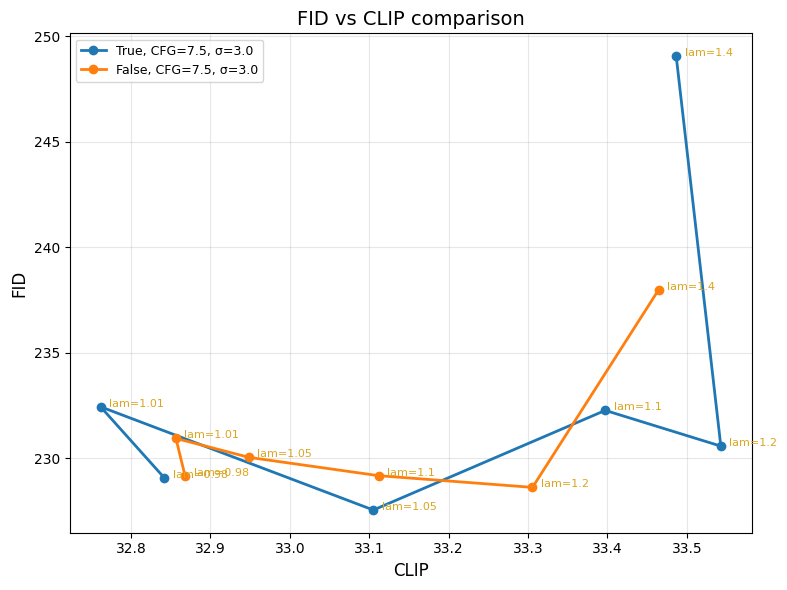

{True: {1.4: (np.float64(249.0521514618094), np.float64(33.486490317753386)),
  1.2: (np.float64(230.56589379653394), np.float64(33.54271405083792)),
  1.1: (np.float64(232.25862550696908), np.float64(33.397155557359966)),
  1.01: (np.float64(232.43098420884894), np.float64(32.76166834150042)),
  1.05: (np.float64(227.53729406248348), np.float64(33.105194909232004)),
  0.98: (np.float64(229.05826570153354), np.float64(32.842063426971436))},
 False: {1.4: (np.float64(237.9875232571515), np.float64(33.46460887363979)),
  1.2: (np.float64(228.6106915896057), np.float64(33.305552278246196)),
  1.1: (np.float64(229.1650230730329), np.float64(33.1118609564645)),
  1.01: (np.float64(230.93075862610084), np.float64(32.85659108843122)),
  1.05: (np.float64(230.03201882522046), np.float64(32.94875628607614)),
  0.98: (np.float64(229.1270429739315), np.float64(32.86826889855521))}}

In [1]:
from fid import compute_sweep
from config import LAM_VALUES, PT_TSR_DIR, TSR_DIR
compute_sweep(
	lam_values=LAM_VALUES,
	replica_exchanges=[True, False],
	device="cuda",
	target_indices=None,
	index_until = 28,
	pt_sr_dir = PT_TSR_DIR,
	tsr_dir = TSR_DIR,
)